<a href="https://colab.research.google.com/github/ORIE5355/project_competition_public/blob/main/run_gym_headtohead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ORIE 5355 Project Demo

This year's class project will be done in two parts:
- Part 1 is a test of your ability to do effective personalized pricing under capacity constrants. You will receive a sample of training data, containing [customer covariates, price offered, whether purchased], based on which you can train a model to predict true customer valuation of the product, given a set of new covariates. You goal is to set prices for each arriving customer, upon observing their covariates, to maximize your long-term revenue/profit. You will be doing so under capacity constraint: for every 20 arriving customers, you have some number of units between 7 and 20 of product available to sell them. 
- Part 2 further takes the above setting under a pricing competition framework: you will compete against every other team's agent to win over each customer. Again, you will each have some number of units of product for every 20 arriving customers.

Throughout the project, we will assume that whenever the customer's true valuation is below the price offered, the customer will make purchase with certainty.

This note book provides a way for you to test your strategy locally.

In [18]:
import numpy as np 
import matplotlib.pyplot as plt
import time
from IPython import display

In [20]:
import make_env_2025 as make_env

### Part 1

In [23]:
# In part 1, each team's agent will be evaluated alone.
project_part = 1
agentnames = ['main']

In [25]:
env, agents = make_env.make_env_agents(
    agentnames = agentnames, 
    project_part = project_part, 
    first_file = 'data/datafile1_2025.csv', 
    second_file='data/datafile2_2025.csv'
    )

# you can replace the agentnames to match whatever agentfiles you create. 
# but in your final submission your agentnames should be '$yourname'.

In [26]:
T = 500 #2500
verbose = False

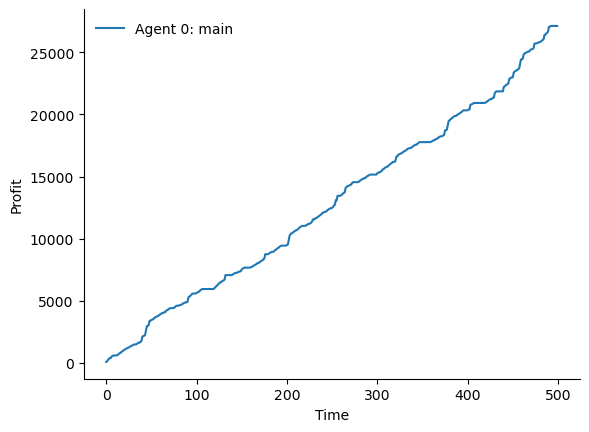

Cumulative profit: [27128.489720886027]
Cumulative buyer utility: [3194.39325759]


In [27]:
env.reset()
customer_covariates, sale, profits, inventories, time_until_replenish = env.get_current_state_customer_to_send_agents()
last_customer_covariates = customer_covariates
inventory_history = []

fig, ax = plt.subplots(figsize=(20, 10))
for t in range(0, T):
    actions = [agent.action((customer_covariates, sale, profits, inventories, time_until_replenish)) for agent in agents]
    customer_covariates, sale, profits, inventories, time_until_replenish = env.step(actions)
    inventory_history.append(inventories[0])
    newplot = env.render(True)
    if newplot:
        display.clear_output(wait=True)
        display.display(plt.gcf())
    if verbose:
        print('last customer covariate: ', last_customer_covariates)
        print('last (item bought, agent bought from, prices): ', sale)
        print('current_profit per agent: ', profits)
    last_customer_covariates = customer_covariates

plt.close()
print("Cumulative profit: {}".format(env.agent_profits))
print("Cumulative buyer utility: {}".format(env.cumulative_buyer_utility))

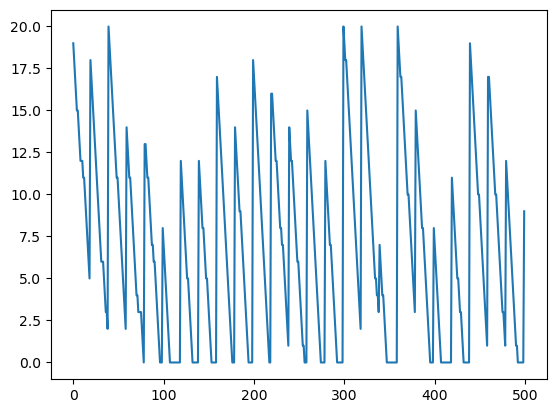

In [28]:
plt.plot(inventory_history)

### Part 2

In [32]:
# In part 2, each team's agent will be evaluated against all other teams.
project_part = 2
agentnames = ['main', 'dummy_fixed_prices_adaptive']

In [33]:
env, agents = make_env.make_env_agents(
    agentnames = agentnames, 
    project_part = project_part, 
    first_file = 'data/datafile1_2025.csv', 
    second_file='data/datafile2_2025.csv'
    )

In [34]:
T = 500 #2500
verbose = False

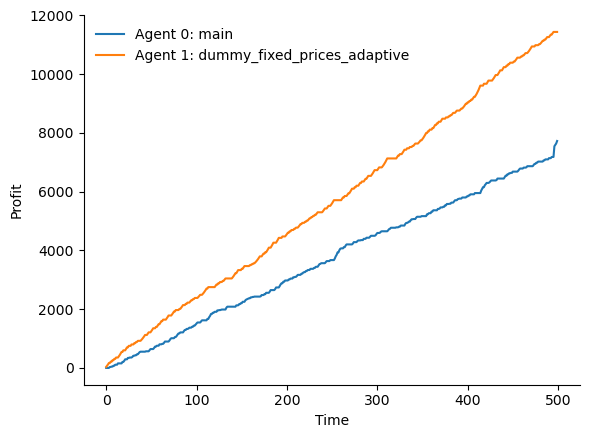

Cumulative profit: [7726.262694668598, 11439.771565615047]
Cumulative buyer utility: [13827.35021289]


In [35]:
# Note that under competition, the dummy 'yourteamname' agant performs much worse than without competition

env.reset()
customer_covariates, sale, profits, inventories, time_until_replenish = env.get_current_state_customer_to_send_agents()
last_customer_covariates = customer_covariates
inventory_history = [[], []]

fig, ax = plt.subplots(figsize=(20, 10))
for t in range(0, T):
    actions = [agent.action((customer_covariates, sale, profits, inventories, time_until_replenish)) for agent in agents]
    customer_covariates, sale, profits, inventories, time_until_replenish = env.step(actions)
    inventory_history[0].append(inventories[0])
    inventory_history[1].append(inventories[1])
    newplot = env.render(True)
    if newplot:
        display.clear_output(wait=True)
        display.display(plt.gcf())
    if verbose:
        print('last customer covariate: ', last_customer_covariates)
        print('last (item bought, agent bought from, prices): ', sale)
        print('current_profit per agent: ', profits)
    last_customer_covariates = customer_covariates

plt.close()
print("Cumulative profit: {}".format(env.agent_profits))
print("Cumulative buyer utility: {}".format(env.cumulative_buyer_utility))

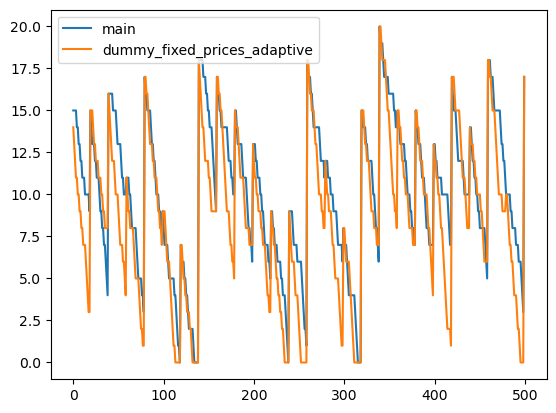

In [36]:
plt.plot(inventory_history[0], label = agentnames[0])
plt.plot(inventory_history[1], label = agentnames[1])
plt.legend()

In [44]:
import time
import numpy as np
from settings import default_params_1
import agents

def generate_sample_observation():
    """Generate a sample observation tuple for testing."""
    new_buyer_covariates = np.array([np.random.uniform(0, 1) for _ in range(3)])
    last_sale = (np.nan, np.array([50.0]))
    state = np.array([0.0])
    inventories = np.array([10])
    time_until_replenish = 15
    return (new_buyer_covariates, last_sale, state, inventories, time_until_replenish)

agent_name = "main"
agent_module = agents.load(agent_name + ".py")
agent = agent_module.Agent(0, default_params_1)

print("Running warm-up...")
obs = generate_sample_observation()
_ = agent.action(obs)
print("Warm-up complete\n")

n_trials = 100
print(f"Running {n_trials} timing trials...")
times = []
for i in range(n_trials):
    obs = generate_sample_observation()
    start = time.perf_counter()
    _ = agent.action(obs)
    end = time.perf_counter()
    times.append((end - start) * 1000)  # Convert to milliseconds

times = np.array(times)
avg_time = np.mean(times)
max_time = np.max(times)
min_time = np.min(times)
median_time = np.median(times)
p95_time = np.percentile(times, 95)
p99_time = np.percentile(times, 99)

print("="*60)
print("Timing Results")
print("="*60)
print(f"Number of trials: {n_trials}")
print(f"\nTiming Statistics (in milliseconds):")
print(f"  Average:     {avg_time:.2f} ms")
print(f"  Median:      {median_time:.2f} ms")
print(f"  Min:         {min_time:.2f} ms")
print(f"  Max:         {max_time:.2f} ms")
print(f"  95th percentile: {p95_time:.2f} ms")
print(f"  99th percentile: {p99_time:.2f} ms")
print(f"\nRequirement: ≤500 ms per decision")

passes = max_time <= 500.0
if passes:
    print(f"Status: PASS (all decisions under 500ms)")
else:
    print(f"Status: FAIL (max time {max_time:.2f} ms exceeds 500 ms limit)")

print("="*60)
# the warnings below are due to not initializing the column names doe the df. This is to optimize the runtime for the code and can be ignored.

Running warm-up...
Warm-up complete

Running 100 timing trials...


C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p

Timing Results
Number of trials: 100

Timing Statistics (in milliseconds):
  Average:     2.94 ms
  Median:      2.65 ms
  Min:         1.62 ms
  Max:         9.36 ms
  95th percentile: 5.41 ms
  99th percentile: 6.07 ms

Requirement: ≤500 ms per decision
Status: PASS (all decisions under 500ms)


C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p

In [46]:
# REVENUE TEST - Complete code with import
import make_env_2025 as make_env

# Configuration
agent_name = "main"
n_simulations = 3  # Number of simulation runs
n_steps = 100      # Number of customers (each step = 1 customer arriving)
seed = None         # Set to a number for reproducibility (e.g., 42)

print(f"Testing {agent_name} agent revenue performance...")
print(f"Running {n_simulations} simulations with {n_steps} steps each...\n")

# Track results
final_profits = []
buyer_utilities = []
start_time = time.perf_counter()

for sim_num in range(n_simulations):
    # Set seed for reproducibility
    if seed is not None:
        np.random.seed(seed + sim_num)
    
    # Create environment and agent
    env, agent_list = make_env.make_env_agents(
        agentnames=[agent_name], 
        project_part=1,
        first_file='data/datafile1_2025.csv', 
        second_file='data/datafile2_2025.csv'
    )
    agent = agent_list[0]
    
    # Reset environment
    env.reset()
    customer_covariates, last_sale, state, inventories, time_until_replenish = \
        env.get_current_state_customer_to_send_agents()
    
    # Run simulation
    for t in range(n_steps):
        action = agent.action((customer_covariates, last_sale, state, inventories, time_until_replenish))
        customer_covariates, last_sale, state, inventories, time_until_replenish = \
            env.step([action])
    
    # Get final metrics
    final_profit = env.agent_profits[0]
    cumulative_buyer_utility = env.cumulative_buyer_utility
    
    final_profits.append(final_profit)
    buyer_utilities.append(cumulative_buyer_utility)
    
    # Progress update
    if (sim_num + 1) % max(1, n_simulations // 10) == 0:
        print(f"Completed {sim_num + 1}/{n_simulations} simulations...")

elapsed_time = time.perf_counter() - start_time

# Calculate statistics
final_profits = np.array(final_profits)
buyer_utilities = np.array(buyer_utilities)

profit_stats = {
    'mean': np.mean(final_profits),
    'median': np.median(final_profits),
    'std': np.std(final_profits),
    'min': np.min(final_profits),
    'max': np.max(final_profits),
    'p25': np.percentile(final_profits, 25),
    'p75': np.percentile(final_profits, 75),
    'p95': np.percentile(final_profits, 95),
}

utility_stats = {
    'mean': np.mean(buyer_utilities),
    'median': np.median(buyer_utilities),
    'std': np.std(buyer_utilities),
}

# Print results
print(f"\n{'='*70}")
print(f"Revenue Test Results for {agent_name}")
print(f"{'='*70}")
print(f"Number of simulations: {n_simulations}")
print(f"Steps per simulation: {n_steps}")
print(f"Total elapsed time: {elapsed_time:.2f} seconds")
print(f"\nProfit Statistics:")
print(f"  Mean:        {profit_stats['mean']:.2f}")
print(f"  Median:      {profit_stats['median']:.2f}")
print(f"  Std Dev:     {profit_stats['std']:.2f}")
print(f"  Min:         {profit_stats['min']:.2f}")
print(f"  Max:         {profit_stats['max']:.2f}")
print(f"  25th percentile: {profit_stats['p25']:.2f}")
print(f"  75th percentile: {profit_stats['p75']:.2f}")
print(f"  95th percentile: {profit_stats['p95']:.2f}")
print(f"\nBuyer Utility Statistics:")
print(f"  Mean:        {utility_stats['mean']:.2f}")
print(f"  Median:      {utility_stats['median']:.2f}")
print(f"  Std Dev:     {utility_stats['std']:.2f}")
print(f"{'='*70}\n")

Testing main agent revenue performance...
Running 3 simulations with 100 steps each...



C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p

Completed 1/3 simulations...


C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p

Completed 2/3 simulations...


C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p

Completed 3/3 simulations...

Revenue Test Results for main
Number of simulations: 3
Steps per simulation: 100
Total elapsed time: 128.21 seconds

Profit Statistics:
  Mean:        4672.26
  Median:      4647.82
  Std Dev:     416.03
  Min:         4175.39
  Max:         5193.57
  25th percentile: 4411.60
  75th percentile: 4920.70
  95th percentile: 5139.00

Buyer Utility Statistics:
  Mean:        482.17
  Median:      514.14
  Std Dev:     70.89



C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhoom\anaconda3\Lib\site-p